In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# ==============================
# CSV FILES
# ==============================

antaranews = pd.read_csv("/content/Cleaned_Antaranews_v1.csv", sep=',', engine='python', on_bad_lines='skip')
detik = pd.read_csv("/content/Cleaned_Detik_v2.csv", sep=',', engine='python', on_bad_lines='skip')
kompas_csv = pd.read_csv("/content/Cleaned_Kompas_v2.csv", sep=',', engine='python', on_bad_lines='skip')
turnback_csv = pd.read_csv("/content/Cleaned_TurnBackHoax_v3.csv", sep=',', engine='python', on_bad_lines='skip')
komdigi = pd.read_csv("/content/komdigi_hoaks.csv")

# ==============================
# EXCEL FILES
# ==============================

cnn = pd.read_excel("/content/dataset_cnn_10k.xlsx")
kompas_xlsx = pd.read_excel("/content/dataset_kompas_4k.xlsx")
tempo = pd.read_excel("/content/dataset_tempo_6k.xlsx")
turnback_xlsx = pd.read_excel("/content/dataset_turnbackhoax_10k.xlsx")

In [ ]:
datasets = {
    "antaranews": antaranews,
    "detik": detik,
    "kompas_csv": kompas_csv,
    "turnback_csv": turnback_csv,
    "komdigi": komdigi,
    "cnn": cnn,
    "kompas_xlsx": kompas_xlsx,
    "tempo": tempo,
    "turnback_xlsx": turnback_xlsx
}

for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print(df.columns)
    print(df.shape)


ANTARANEWS
Index(['url', 'judul', 'narasi', 'label', 'clean_text'], dtype='object')
(5926, 5)

DETIK
Index(['url', 'judul', 'narasi', 'label', 'clean_text'], dtype='object')
(6318, 5)

KOMPAS_CSV
Index(['url', 'judul', 'narasi', 'label', 'clean_text'], dtype='object')
(6429, 5)

TURNBACK_CSV
Index(['url', 'judul', 'narasi', 'label', 'clean_text'], dtype='object')
(24208, 5)

KOMDIGI
Index(['id', 'url', 'title', 'slug', 'published_at', 'view_count', 'excerpt',
       'body_html', 'body_text', 'main_image_url', 'category', 'tags',
       'topics'],
      dtype='object')
(2460, 13)

CNN
Index(['Title', 'Timestamp', 'FullText', 'Tags', 'Author', 'Url'], dtype='object')
(10000, 6)

KOMPAS_XLSX
Index(['Title', 'Timestamp', 'FullText', 'Tags', 'Author', 'Url'], dtype='object')
(4750, 6)

TEMPO
Index(['Title', 'Timestamp', 'FullText', 'Tags', 'Author', 'Url'], dtype='object')
(6592, 6)

TURNBACK_XLSX
Index(['Title', 'Timestamp', 'FullText', 'Tags', 'Author', 'Url'], dtype='object')
(10384, 6)

In [ ]:
import pandas as pd

# =========================
# ROBUST HELPER FUNCTION
# =========================

def standardize_dataframe(
    df,
    source_name,
    title_col,
    content_col,
    url_col=None,
    label_col=None,
    force_label=None
):
    """
    Standardize dataframe into:
    source | title | content | label | url
    """

    # VALIDATION
    if title_col not in df.columns:
        raise ValueError(f"{source_name}: title_col '{title_col}' not found")
    if content_col not in df.columns:
        raise ValueError(f"{source_name}: content_col '{content_col}' not found")

    # Initialize standardized DataFrame with the same index as the input df
    standardized = pd.DataFrame(index=df.index)

    standardized["source"] = source_name
    standardized["title"] = df[title_col]
    standardized["content"] = df[content_col]

    # LABEL HANDLING
    if force_label is not None:
        standardized["label"] = force_label
    elif label_col:
        if label_col not in df.columns:
            raise ValueError(f"{source_name}: label_col '{label_col}' not found")
        standardized["label"] = df[label_col]
    else:
        raise ValueError(f"{source_name}: Must provide force_label or label_col")

    # URL
    if url_col and url_col in df.columns:
        standardized["url"] = df[url_col]
    else:
        standardized["url"] = None

    return standardized


# =========================
# STANDARDIZE EACH DATASET
# =========================

# 1️⃣ CNN (legit)
cnn_clean = standardize_dataframe(
    cnn,
    source_name="cnn",
    title_col="Title",
    content_col="FullText", # Corrected from 'text_new'
    url_col="Url",
    force_label=0
)

# 2️⃣ Kompas XLSX (legit only)
kompas_xlsx_clean = standardize_dataframe(
    kompas_xlsx,
    source_name="kompas_xlsx",
    title_col="Title",
    content_col="FullText", # Corrected from 'text_new'
    url_col="Url",
    force_label=0
)

# 3️⃣ Tempo (legit)
tempo_clean = standardize_dataframe(
    tempo,
    source_name="tempo",
    title_col="Title",
    content_col="FullText", # Corrected from 'text_new'
    url_col="Url",
    force_label=0
)

# 4️⃣ TurnBackHoax XLSX (HOAX)
turnback_xlsx_clean = standardize_dataframe(
    turnback_xlsx,
    source_name="turnback_xlsx",
    title_col="Title",
    content_col="FullText",   # Corrected from 'Clean Narasi'
    url_col="Url",
    force_label=1
)

# 5️⃣ Antara (legit)
antaranews_clean = standardize_dataframe(
    antaranews,
    source_name="antaranews",
    title_col="judul", # Changed from 'Title'
    content_col="clean_text", # Changed from 'text_new'
    url_col="url", # Changed from 'Url'
    force_label=0
)

# 6️⃣ Detik (legit)
detik_clean = standardize_dataframe(
    detik,
    source_name="detik",
    title_col="judul", # Changed from 'Title'
    content_col="clean_text", # Changed from 'text_new'
    url_col="url", # Changed from 'Url'
    force_label=0
)

# 7️⃣ Kompas CSV (legit)
kompas_csv_clean = standardize_dataframe(
    kompas_csv,
    source_name="kompas_csv",
    title_col="judul", # Changed from 'Title'
    content_col="clean_text", # Changed from 'text_new'
    url_col="url", # Changed from 'Url'
    force_label=0
)

# 8️⃣ TurnBackHoax CSV (HOAX)
turnback_csv_clean = standardize_dataframe(
    turnback_csv,
    source_name="turnback_csv",
    title_col="judul", # Changed from 'Title'
    content_col="narasi",   # Changed from 'Clean Narasi'
    url_col="url", # Changed from 'Url'
    force_label=1
)

# 9️⃣ Komdigi (HOAX)
komdigi_clean = standardize_dataframe(
    komdigi,
    source_name="komdigi",
    title_col="title",
    content_col="body_text",  # 🔥 FIXED
    url_col="url",
    force_label=1
)


# =========================
# MERGE ALL
# =========================

df_final = pd.concat([
    cnn_clean,
    kompas_xlsx_clean,
    tempo_clean,
    turnback_xlsx_clean,
    antaranews_clean,
    detik_clean,
    kompas_csv_clean,
    turnback_csv_clean,
    komdigi_clean
], ignore_index=True)


# =========================
# CLEAN FINAL DATA
# =========================

df_final = df_final.dropna(subset=["content"])
df_final = df_final.drop_duplicates(subset=["content"])
df_final = df_final.reset_index(drop=True)

print("Final Dataset Shape:", df_final.shape)
print("\nLabel Distribution:")
print(df_final["label"].value_counts())
print("\nSource Distribution:")
print(df_final["source"].value_counts())

Final Dataset Shape: (54948, 5)

Label Distribution:
label
0    31815
1    23133
Name: count, dtype: int64

Source Distribution:
source
turnback_xlsx    10366
turnback_csv     10312
cnn               9630
tempo             6591
kompas_xlsx       4723
antaranews        3873
detik             3500
kompas_csv        3498
komdigi           2455
Name: count, dtype: int64


In [ ]:
# =====================================================
# 5️⃣ TRAIN / TEST SPLIT
# =====================================================

X = df_final["content"]
y = df_final["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42)

In [ ]:
vectorizer = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1,2),
    min_df=5
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# =====================================================
# 7️⃣ DEFINE MODELS
# =====================================================

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Linear SVM": LinearSVC(class_weight="balanced"),
    "Naive Bayes": MultinomialNB()
}



========== Logistic Regression ==========


<Figure size 800x600 with 0 Axes>

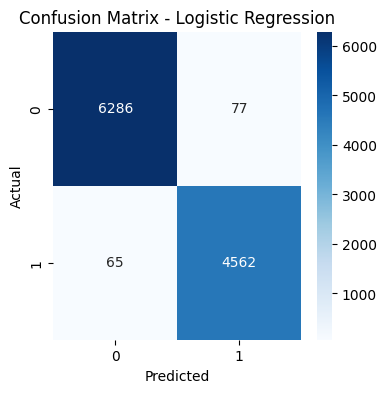

ROC AUC: 0.9985074520913451
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      6363
           1       0.98      0.99      0.98      4627

    accuracy                           0.99     10990
   macro avg       0.99      0.99      0.99     10990
weighted avg       0.99      0.99      0.99     10990


========== Linear SVM ==========


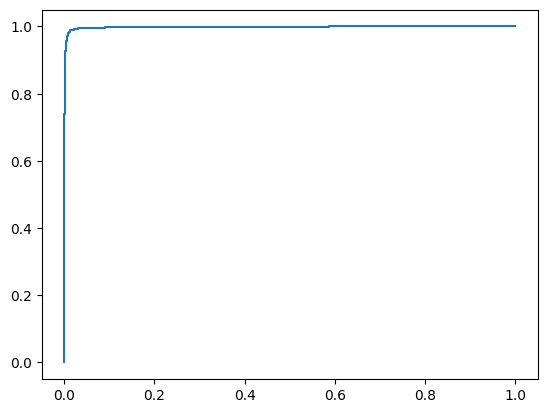

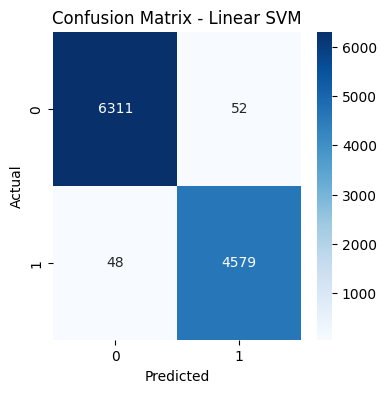

ROC AUC: Not available (no probability output)
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      6363
           1       0.99      0.99      0.99      4627

    accuracy                           0.99     10990
   macro avg       0.99      0.99      0.99     10990
weighted avg       0.99      0.99      0.99     10990


========== Naive Bayes ==========


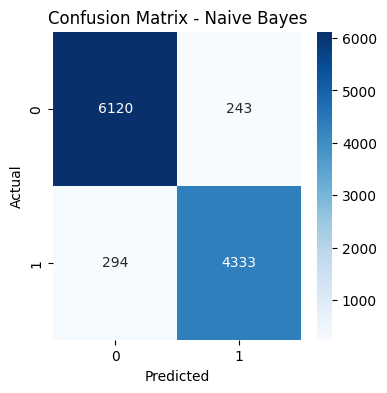

ROC AUC: 0.9908292011701401
              precision    recall  f1-score   support

           0       0.95      0.96      0.96      6363
           1       0.95      0.94      0.94      4627

    accuracy                           0.95     10990
   macro avg       0.95      0.95      0.95     10990
weighted avg       0.95      0.95      0.95     10990



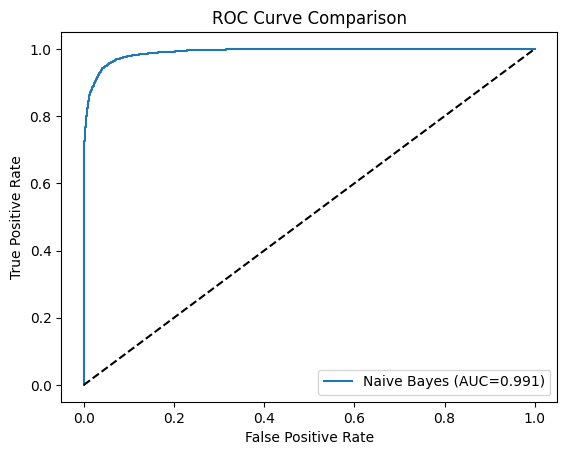

In [ ]:
# =====================================================
# 8️⃣ TRAIN & EVALUATE + VISUALIZATION
# =====================================================

plt.figure(figsize=(8,6))

for name, model in models.items():
    print(f"\n========== {name} ==========")

    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
# ROC Curve
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_tfidf)[:,1]
        roc = roc_auc_score(y_test, y_prob)
        print("ROC AUC:", roc)

        from sklearn.metrics import roc_curve
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc:.3f})")
    else:
        print("ROC AUC: Not available (no probability output)")

    print(classification_report(y_test, y_pred))

# Plot ROC comparison
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


========== Calibrated SVM ==========


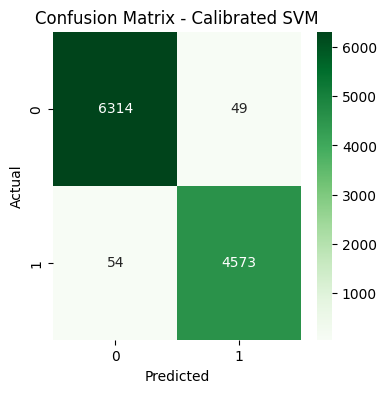

ROC AUC: 0.9992696049375848


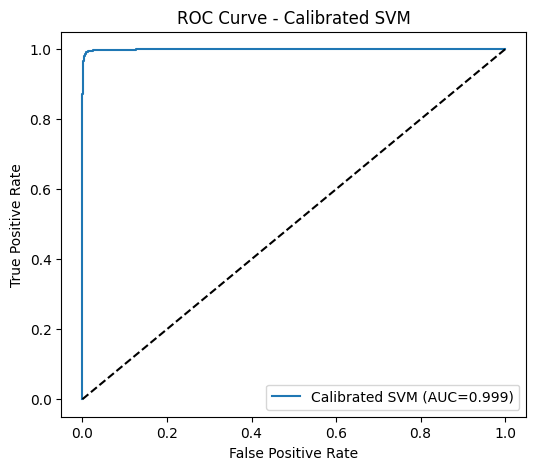

In [ ]:

# =====================================================
# 9️⃣ CALIBRATED SVM (WITH ROC)
# =====================================================

print("\n========== Calibrated SVM ==========")
svm = LinearSVC(class_weight="balanced")
calibrated_svm = CalibratedClassifierCV(svm)
calibrated_svm.fit(X_train_tfidf, y_train)

y_pred = calibrated_svm.predict(X_test_tfidf)
y_prob = calibrated_svm.predict_proba(X_test_tfidf)[:,1]

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - Calibrated SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

roc = roc_auc_score(y_test, y_prob)
print("ROC AUC:", roc)
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"Calibrated SVM (AUC={roc:.3f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Calibrated SVM")
plt.legend()
plt.show()

# =====================================================
# END
# =====================================================


In [ ]:
# =====================================================
# 🔟 SELECT BEST MODEL & SAVE ALL MODELS TO GOOGLE DRIVE
# =====================================================

import os
import joblib
import pandas as pd
from google.colab import drive
from sklearn.metrics import roc_auc_score

# =====================================================
# MOUNT GOOGLE DRIVE
# =====================================================

drive.mount('/content/drive')

SAVE_DIR = "/content/drive/MyDrive/saved_models"
os.makedirs(SAVE_DIR, exist_ok=True)

print("📂 Saving models to:", SAVE_DIR)

# =====================================================
# TRAIN AGAIN + CALCULATE ROC
# =====================================================

model_performance = []
trained_models = {}

for name, model in models.items():

    print(f"\n🔧 Training {name} for saving...")

    model.fit(X_train_tfidf, y_train)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_tfidf)[:,1]
        roc = roc_auc_score(y_test, y_prob)

    else:
        # handle SVM without probability
        svm = LinearSVC(class_weight="balanced")
        calibrated = CalibratedClassifierCV(svm)
        calibrated.fit(X_train_tfidf, y_train)

        y_prob = calibrated.predict_proba(X_test_tfidf)[:,1]
        roc = roc_auc_score(y_test, y_prob)

        model = calibrated

    print(f"ROC AUC ({name}): {roc:.4f}")

    model_performance.append((name, roc))
    trained_models[name] = model

    # SAVE MODEL
    model_path = f"{SAVE_DIR}/{name}_model.pkl"
    joblib.dump(model, model_path)

    print(f"💾 Saved model: {model_path}")


# =====================================================
# ADD CALIBRATED SVM TO SAVED MODELS
# =====================================================

print("\n🔧 Saving Calibrated SVM...")

y_prob = calibrated_svm.predict_proba(X_test_tfidf)[:,1]
roc = roc_auc_score(y_test, y_prob)

model_performance.append(("Calibrated_SVM", roc))
trained_models["Calibrated_SVM"] = calibrated_svm

joblib.dump(calibrated_svm, f"{SAVE_DIR}/calibrated_svm_model.pkl")

print("💾 Saved: calibrated_svm_model.pkl")


# =====================================================
# SELECT BEST MODEL
# =====================================================

best_model_name, best_score = max(model_performance, key=lambda x: x[1])
best_model = trained_models[best_model_name]

print("\n🏆 BEST MODEL:", best_model_name)
print("Best ROC AUC:", best_score)


# =====================================================
# RETRAIN BEST MODEL WITH FULL DATASET
# =====================================================

print("\n🔄 Retraining best model on FULL dataset...")

X_full_tfidf = vectorizer.fit_transform(df_final["content"])
best_model.fit(X_full_tfidf, df_final["label"])


# =====================================================
# SAVE BEST MODEL + VECTORIZER
# =====================================================

joblib.dump(best_model, f"{SAVE_DIR}/best_hoax_model.pkl")
joblib.dump(vectorizer, f"{SAVE_DIR}/tfidf_vectorizer.pkl")

print("💾 Best model + vectorizer saved")


# =====================================================
# SAVE MODEL PERFORMANCE REPORT
# =====================================================

performance_df = pd.DataFrame(model_performance, columns=["Model", "ROC_AUC"])
performance_df.sort_values("ROC_AUC", ascending=False, inplace=True)

performance_path = f"{SAVE_DIR}/model_performance.csv"
performance_df.to_csv(performance_path, index=False)

print("📊 Performance report saved:", performance_path)


# =====================================================
# FINAL SUMMARY
# =====================================================

print("\n✅ ALL MODELS SAVED SUCCESSFULLY")
print("📂 Location:", SAVE_DIR)
print("Files saved:")
print("• All trained models (.pkl)")
print("• Best hoax detection model")
print("• TF-IDF vectorizer")
print("• Model performance report")

Mounted at /content/drive
📂 Saving models to: /content/drive/MyDrive/saved_models

🔧 Training Logistic Regression for saving...
ROC AUC (Logistic Regression): 0.9985
💾 Saved model: /content/drive/MyDrive/saved_models/Logistic Regression_model.pkl

🔧 Training Linear SVM for saving...
ROC AUC (Linear SVM): 0.9993
💾 Saved model: /content/drive/MyDrive/saved_models/Linear SVM_model.pkl

🔧 Training Naive Bayes for saving...
ROC AUC (Naive Bayes): 0.9908
💾 Saved model: /content/drive/MyDrive/saved_models/Naive Bayes_model.pkl

🔧 Saving Calibrated SVM...
💾 Saved: calibrated_svm_model.pkl

🏆 BEST MODEL: Linear SVM
Best ROC AUC: 0.9992696049375848

🔄 Retraining best model on FULL dataset...
💾 Best model + vectorizer saved
📊 Performance report saved: /content/drive/MyDrive/saved_models/model_performance.csv

✅ ALL MODELS SAVED SUCCESSFULLY
📂 Location: /content/drive/MyDrive/saved_models
Files saved:
• All trained models (.pkl)
• Best hoax detection model
• TF-IDF vectorizer
• Model performance r